In [5]:
# Подключаем Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
# Распаковываем оба архива
import zipfile, os

print('Распаковываем seg_train...')
with zipfile.ZipFile('/content/drive/MyDrive/seg_train.zip', 'r') as zf:
    zf.extractall('/content/data')

print('Распаковываем seg_test...')
with zipfile.ZipFile('/content/drive/MyDrive/seg_test.zip', 'r') as zf:
    zf.extractall('/content/data')

print('Готово!')

Распаковываем seg_train...
Распаковываем seg_test...
Готово!


In [8]:
# Проверяем структуру
for root, dirs, files in os.walk('/content/data'):
    level = root.replace('/content/data', '').count(os.sep)
    if level <= 2:
        print('  ' * level + os.path.basename(root) + '/')

data/
  seg_train/
    street/
    buildings/
    sea/
    glacier/
    mountain/
    forest/
  seg_test/
    street/
    buildings/
    sea/
    glacier/
    mountain/
    forest/


In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

TRAIN_DIR = '/content/data/seg_train'
TEST_DIR  = '/content/data/seg_test'
CLASSES   = sorted(os.listdir(TRAIN_DIR))
print('Классы:', CLASSES)

Классы: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [10]:
# Количество изображений по классам
for cls in CLASSES:
    n_train = len(os.listdir(f'{TRAIN_DIR}/{cls}'))
    n_test  = len(os.listdir(f'{TEST_DIR}/{cls}'))
    print(f'{cls:12s}  train: {n_train}   test: {n_test}')

buildings     train: 2191   test: 437
forest        train: 2271   test: 474
glacier       train: 2404   test: 553
mountain      train: 2512   test: 525
sea           train: 2274   test: 510
street        train: 2382   test: 501


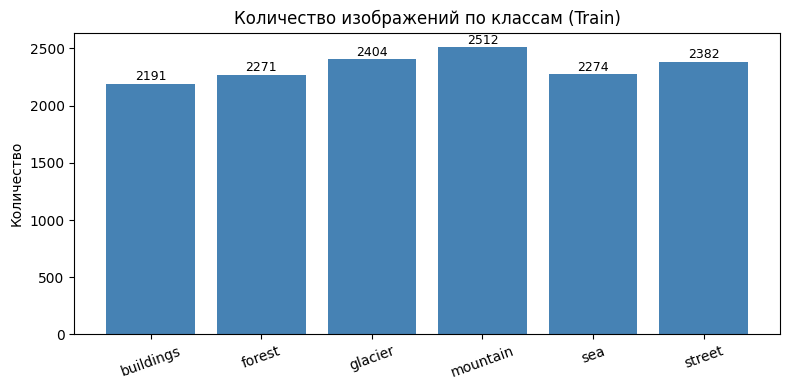

In [11]:
# График распределения классов
counts = [len(os.listdir(f'{TRAIN_DIR}/{cls}')) for cls in CLASSES]

plt.figure(figsize=(8, 4))
plt.bar(CLASSES, counts, color='steelblue')
plt.title('Количество изображений по классам (Train)')
plt.xticks(rotation=20)
plt.ylabel('Количество')
for i, v in enumerate(counts):
    plt.text(i, v + 30, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

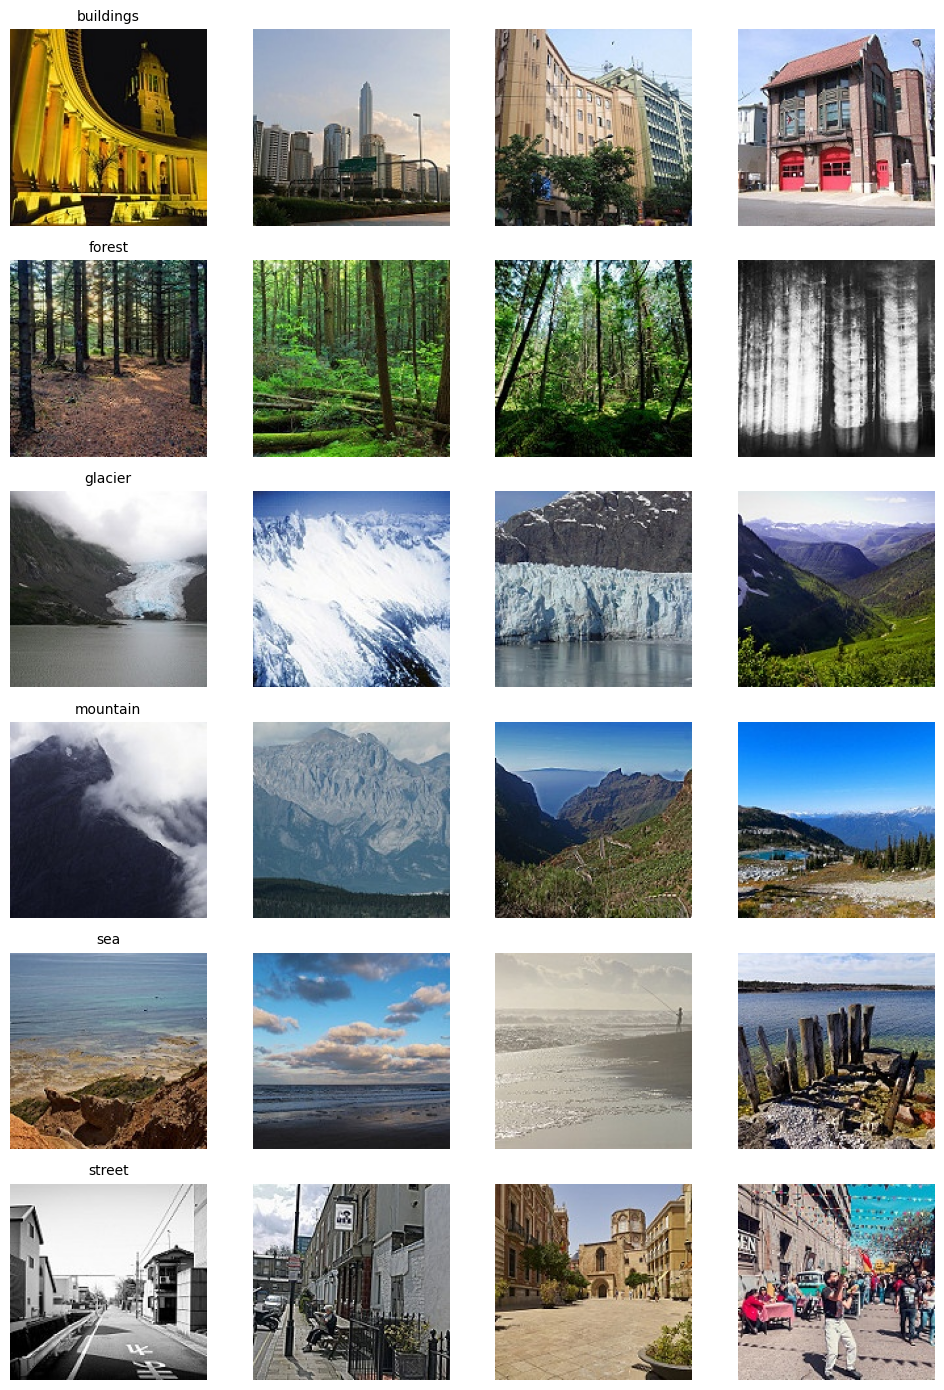

In [12]:
# Примеры изображений
fig, axes = plt.subplots(6, 4, figsize=(10, 14))
for row, cls in enumerate(CLASSES):
    imgs = os.listdir(f'{TRAIN_DIR}/{cls}')[:4]
    for col, fname in enumerate(imgs):
        img = np.array(Image.open(f'{TRAIN_DIR}/{cls}/{fname}').resize((150, 150)))
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_title(cls, fontsize=10)
plt.tight_layout()
plt.show()